In [16]:
! pip install langchain langchain-community langgraph python-dotenv faiss-cpu pypdf langchain_text_splitters langchain_groq sentence-transformers langchain-core


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic import BaseModel

load_dotenv()

True

In [4]:
docs = (PyPDFLoader("./documents/book1.pdf").load()+ PyPDFLoader("./documents/book2.pdf").load()+PyPDFLoader("./documents/book3.pdf").load())

In [7]:
len(docs)

2123

In [8]:
#2 chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150).split_documents(docs)

#3 clean text to avoid UnicodeEncodeError (Surrogate from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode('utf-8', 'ignore').decode('utf-8')

In [12]:
len(chunks)

5766

In [10]:
# 3 Embbeding 
#Embedding the chunks and store in FAISS vector store
embedding = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    encode_kwargs={"normalize_embeddings": True}
)

C:\Users\sushil verma\AppData\Local\Temp\ipykernel_10544\38298951.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4430.01it/s]


In [11]:
# store the embeddings in FAISS vector store
vector_store = FAISS.from_documents(chunks, embedding)

In [12]:
# Retriever the top 4 relevant chunks
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [13]:
# model for question answering
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [14]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]           # output of decompositions (sentences strips)
    kept_strips: List[str]      # the strips that are kept after relevance checking with retriever   
    refined_context:str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [15]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [16]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [17]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

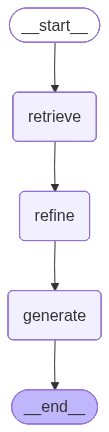

In [18]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine",refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [19]:
# 5) Run
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

BadRequestError: Error code: 400 - {'error': {'message': 'tool call validation failed: parameters for tool KeepOrDrop did not match schema: errors: [`/keep`: expected boolean, but got string]', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=KeepOrDrop>{"keep": "false"}</function>'}}

In [20]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

NameError: name 'res' is not defined

In [ ]:
print(res['refined_context'])

In [ ]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [ ]:
decompose_to_sentences("""A transformer in deep learning is a type of model architecture that is particularly effective for processing sequential data, such as text. It utilizes mechanisms called self-attention and feedforward neural networks to weigh the importance of different parts of the input data, allowing it to capture long-range dependencies and relationships within the data. Unlike traditional recurrent neural networks (RNNs), transformers do not process data sequentially, which enables them to be more parallelizable and efficient in training. This architecture has become foundational in natural language processing tasks and has led to significant advancements in the field.""")